# Relatório de Análise Preditiva e Quantificação de Incerteza
**Objetivo:** Este estudo tem como foco o desenvolvimento de um modelo preditivo para o `Desconto Pix` em calçados de e-commerce (Dafiti). Além da previsão pontual, utilizamos a técnica de **Conformal Prediction** para gerar intervalos de predição estatisticamente válidos, estimando a incerteza do modelo. Por fim, aplicamos o **SHAP (SHapley Additive exPlanations)** para interpretar as decisões do modelo e entender quais atributos geram maior incerteza nas predições.

## 1. Configuração Inicial e Carregamento dos Dados
Nesta etapa, importamos as bibliotecas necessárias e carregamos a base de dados obtida via web scraping.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

pasta_do_script = os.getcwd()
caminho_dados = os.path.abspath(
    os.path.join(pasta_do_script, '..', '00.Dados', '202608_DadosDafiti_Combinados.csv')
)
df = pd.read_csv(caminho_dados)

C:\Users\catit\bia-git\REC\Projeto-REC-Ciencias-de-Dados\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Pré-processamento e Engenharia de Atributos
Para que o modelo possa interpretar as variáveis financeiras, realizamos a limpeza das *strings* de preço (removendo símbolos monetários e ajustando separadores decimais). A variável alvo, `Desconto Pix`, é calculada como a diferença entre o preço original e o preço com desconto. 

Além disso, transformamos variáveis categóricas complexas (como as *tags* de produtos e a quantidade de parcelas) em variáveis indicadoras (*dummy/one-hot encoding*), permitindo que o algoritmo capture esses padrões.

In [2]:
# 1. Definimos as colunas que precisam ser tratadas
colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']

# 2. Loop para tratar cada coluna de preço
for col in colunas_preco:
    nova_coluna = f"{col} Numérico"
    
    # Fazemos a limpeza da string encadeando métodos do pandas
    df[nova_coluna] = (
        df[col]
        .astype(str)                           
        .str.replace('R$', '', regex=False)    
        .str.replace('.', '', regex=False)     
        .str.replace(',', '.', regex=False)    
        .str.strip()                           
    )
    
    # Converte a string tratada para float
    df[nova_coluna] = pd.to_numeric(df[nova_coluna], errors='coerce')

# 3. Cria a coluna de desconto
df['Desconto Pix'] = df['Preço Original Numérico'] - df['Preço Pix Numérico']

# Tratamento da coluna Tags (One-hot encoding multi-label)
df['Tags'] = df['Tags'].fillna('')
colunas_tags = df['Tags'].str.get_dummies(sep=',')
colunas_tags = colunas_tags.add_prefix('Tag_')
df = pd.concat([df, colunas_tags], axis=1)

# Cria as variáveis binárias para a quantidade de parcelas
df = pd.get_dummies(df, columns=['Quantidade de Parcelas'], dtype=int)

## 3. Limpeza Final e Qualidade de Dados
Após a criação das novas variáveis, selecionamos apenas as colunas úteis para a modelagem (descartando os textos brutos). Executamos um diagnóstico de valores ausentes (*missing values*) e optamos pela exclusão das linhas inconsistentes para garantir a estabilidade do treinamento.

In [3]:
# Seleciona as variáveis criadas/numéricas
colunas_selecionadas = df.columns[9:].tolist()
df_modelo = df[colunas_selecionadas]

# Relatório de qualidade
relatorio_qualidade = pd.DataFrame({
    'Valores Ausentes': df_modelo.isnull().sum(),
    'Percentual (%)': (df_modelo.isnull().sum() / len(df_modelo)) * 100
})
relatorio_qualidade = relatorio_qualidade.sort_values(by='Valores Ausentes', ascending=False)
print("Relatório de Valores Ausentes:\n", relatorio_qualidade.head())

# Exclusão de nulos e contagem
linhas_antes = df_modelo.shape[0]
df_modelo = df_modelo.dropna()
linhas_depois = df_modelo.shape[0]

print(f"\nTotal de linhas ANTES da limpeza: {linhas_antes}")
print(f"Total de linhas DEPOIS da limpeza: {linhas_depois}")
print(f"Linhas excluídas: {linhas_antes - linhas_depois}")

Relatório de Valores Ausentes:
                           Valores Ausentes  Percentual (%)
Preço Pix Numérico                    4642       27.910053
Desconto Pix                          4642       27.910053
Preço Original Numérico                  0        0.000000
Preço Parcelado Numérico                 0        0.000000
Tag_Alpargatas                           0        0.000000

Total de linhas ANTES da limpeza: 16632
Total de linhas DEPOIS da limpeza: 11990
Linhas excluídas: 4642


## 4. Particionamento de Dados (Abordagem Conformal)
No *framework* de Conformal Prediction, o particionamento tradicional (Treino e Teste) não é suficiente. Precisamos de um terceiro conjunto: a **Calibração**. 
* **Treino:** Aprende a relação entre as variáveis.
* **Calibração:** Avalia empiricamente os erros do modelo em dados não vistos para estimar o quantil de incerteza (margem de erro).
* **Teste:** Avalia a cobertura e a largura dos intervalos finais.

treino: (7194, 66)
calibracao: (2398, 66)
teste: (2398, 66)


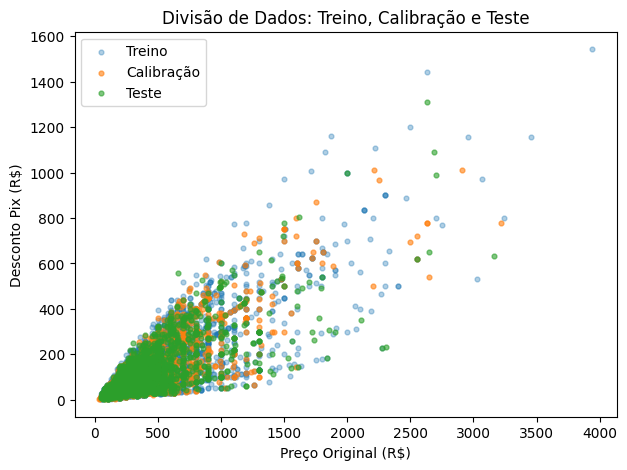

In [4]:
alvo = "Desconto Pix"
alpha = 0.10 # Nível de significância para 90% de cobertura alvo

X = df_modelo.drop(columns=["Desconto Pix", "Preço Pix Numérico"])
y = df_modelo[alvo]

X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_treino_cal, y_treino_cal, test_size=0.25, random_state=42
)

print("treino:", X_treino.shape)
print("calibracao:", X_cal.shape)
print("teste:", X_teste.shape)

coluna_x = "Preço Original Numérico"
plt.figure(figsize=(7, 5))
plt.scatter(X_treino[coluna_x], y_treino, s=12, alpha=0.35, label="Treino")
plt.scatter(X_cal[coluna_x], y_cal, s=12, alpha=0.60, label="Calibração")
plt.scatter(X_teste[coluna_x], y_teste, s=12, alpha=0.60, label="Teste")
plt.title("Divisão de Dados: Treino, Calibração e Teste")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)") 
plt.legend()
plt.show()

- O gráfico de dispersão demonstra uma forte correlação linear positiva entre o "Preço Original (R\\$)" e o "Desconto Pix (R\\$)". Isso indica que produtos mais caros tendem a receber descontos absolutos maiores.
- A distribuição dos dados mostra que o volume de produtos está concentrado na faixa de preço abaixo de R\\$ 1.500, com uma cauda longa de itens mais caros que chegam a quase R\\$ 4.000.
- As três amostras (Treino em azul, Calibração em laranja e Teste em verde) estão bem sobrepostas e distribuídas ao longo de toda a amplitude de preços, o que garante que os dados de calibração e teste são representativos do padrão aprendido no treinamento.

## 5. Modelagem Preditiva e Conformal Prediction (Intervalo Fixo)
Iniciamos com um estimador base (`RandomForestRegressor`). Após o treinamento, calculamos os erros absolutos (resíduos) no conjunto de calibração. O limite do intervalo (*q*) é definido pelo quantil desses erros, garantindo matematicamente a cobertura de 90% (*1 - alpha*). Nesta abordagem, **a largura do intervalo de incerteza é constante para todas as predições**.

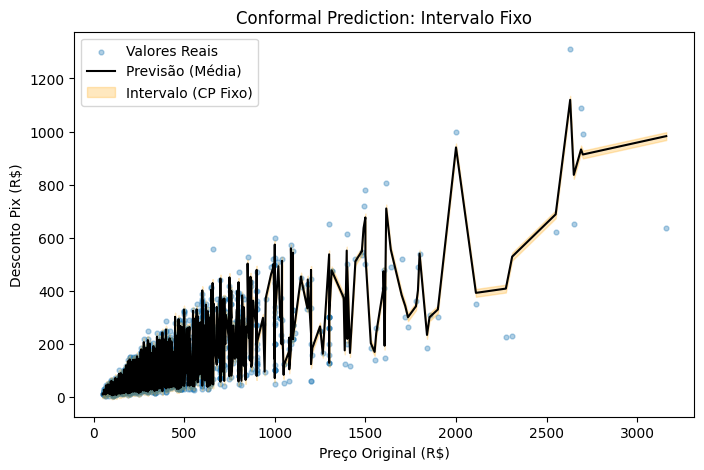

cobertura         0.911176
largura_media    29.593784
mae               6.233894
q                14.796892
dtype: float64


In [5]:
modelo = RandomForestRegressor(
    n_estimators=100, min_samples_leaf=3, n_jobs=-1, random_state=42
)
modelo.fit(X_treino, y_treino)

# Calibração do erro
pred_cal = modelo.predict(X_cal)
erros_cal = np.abs(y_cal - pred_cal)
n_cal = len(erros_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q = np.quantile(erros_cal, nivel_quantil, method="higher")

# Predição e métricas no Teste
pred_teste = modelo.predict(X_teste)
baixo_comum = pred_teste - q
alto_comum = pred_teste + q

cobertura_comum = ((y_teste >= baixo_comum) & (y_teste <= alto_comum)).mean()
largura_comum = np.mean(alto_comum - baixo_comum)
mae_comum = mean_absolute_error(y_teste, pred_teste)

# Plotagem
ordem = np.argsort(X_teste[coluna_x].to_numpy())
x_plot = X_teste[coluna_x].to_numpy()[ordem]
y_plot = y_teste.to_numpy()[ordem]
pred_plot = pred_teste[ordem]
baixo_plot = baixo_comum[ordem]
alto_plot = alto_comum[ordem]

plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_plot, s=12, alpha=0.35, label="Valores Reais")
plt.plot(x_plot, pred_plot, color="black", label="Previsão (Média)")
plt.fill_between(x_plot, baixo_plot, alto_plot, alpha=0.25, color="orange", label="Intervalo (CP Fixo)")
plt.title("Conformal Prediction: Intervalo Fixo")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)")
plt.legend()
plt.show()

print(pd.Series({"cobertura": cobertura_comum, "largura_media": largura_comum, "mae": mae_comum, "q": q}))

- A linha preta da "Previsão (Média)" consegue acompanhar a tendência geral dos "Valores Reais" (pontos azuis), confirmando que o modelo base capturou a relação principal dos dados.
- A faixa de incerteza laranja ("Intervalo (CP Fixo)") possui uma largura estática e imutável para todas as predições, independentemente do preço do calçado.
- Visualmente, nota-se que a variância dos dados aumenta conforme o preço sobe (heteroscedasticidade). O uso de um intervalo fixo aplica uma margem de segurança desnecessariamente larga para os calçados baratos e, potencialmente, uma margem apertada demais para os calçados de alto valor.   

## 6. Conformal Prediction Adaptativo (Modelo de Variância)
Um intervalo fixo pune itens previsíveis e confia demais em itens difíceis. Para corrigir isso, treinamos um **segundo modelo de Random Forest focado na variância**. 
Ele prevê o "tamanho do erro" (resíduos ao quadrado) com base nas características do produto. Assim, os intervalos de predição tornam-se dinâmicos: alargam-se onde o modelo está incerto e estreitam-se onde ele possui alta confiança empírica.

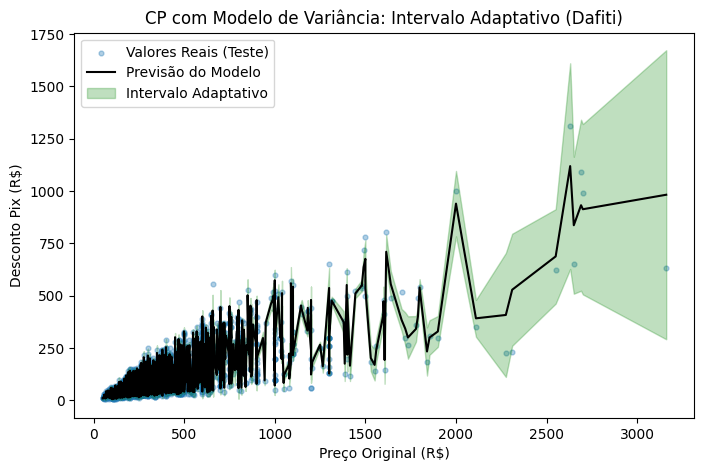

,Método,Cobertura,Largura Média,MAE,q
0,Intervalo Fixo (Comum),0.911176,29.593784,6.233894,14.796892
1,Intervalo Adaptativo (Variância),0.909091,24.442130,6.233894,2.230932


In [6]:
modelo_media = RandomForestRegressor(n_estimators=100, min_samples_leaf=3, n_jobs=-1, random_state=42)
modelo_media.fit(X_treino, y_treino)

# Calcula os resíduos do treino para treinar o modelo de variância
pred_treino = modelo_media.predict(X_treino)
variancia_observada = (y_treino - pred_treino) ** 2

modelo_variancia = RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=42)
modelo_variancia.fit(X_treino, variancia_observada)

# Calibração com escores normalizados
pred_cal_adapt = modelo_media.predict(X_cal)
escala_cal = np.sqrt(modelo_variancia.predict(X_cal))
scores_cal = np.abs(y_cal - pred_cal_adapt) / escala_cal

q_adapt = np.quantile(scores_cal, nivel_quantil, method="higher")

# 1. Previsões e definição da margem de erro na base de Teste
pred_teste_adapt = modelo_media.predict(X_teste)
escala_teste = np.sqrt(np.maximum(modelo_variancia.predict(X_teste), 0)) # np.maximum previne raízes negativas

# O limite agora é dinâmico: depende do q_adapt e da 'escala_teste' de cada produto
baixo_adapt = pred_teste_adapt - q_adapt * escala_teste
alto_adapt = pred_teste_adapt + q_adapt * escala_teste

# 2. Cálculo das métricas
cobertura_adapt = ((y_teste >= baixo_adapt) & (y_teste <= alto_adapt)).mean()
largura_adapt = np.mean(alto_adapt - baixo_adapt)
mae_adapt = mean_absolute_error(y_teste, pred_teste_adapt)

# 3. Preparação para o gráfico (Ordenando pelo Preço Original)
coluna_x = "Preço Original Numérico"
ordem = np.argsort(X_teste[coluna_x].to_numpy())

x_plot = X_teste[coluna_x].to_numpy()[ordem]
y_plot = y_teste.to_numpy()[ordem]
pred_plot_adapt = pred_teste_adapt[ordem]
baixo_plot_adapt = baixo_adapt[ordem]
alto_plot_adapt = alto_adapt[ordem]

# 4. Gráfico do Conformal Prediction Adaptativo
plt.figure(figsize=(8, 5))
plt.scatter(x_plot, y_plot, s=12, alpha=0.35, label="Valores Reais (Teste)")
plt.plot(x_plot, pred_plot_adapt, color="black", label="Previsão do Modelo")

# Faixa adaptativa (vai ficar mais fina onde o modelo tem certeza e mais larga onde tem dúvida)
plt.fill_between(x_plot, baixo_plot_adapt, alto_plot_adapt, alpha=0.25, color="green", label="Intervalo Adaptativo")

plt.title("CP com Modelo de Variância: Intervalo Adaptativo (Dafiti)")
plt.xlabel("Preço Original (R$)")
plt.ylabel("Desconto Pix (R$)")
plt.legend()
plt.show()

# 5. Tabela Comparativa (Fixo vs Adaptativo)
comparacao = pd.DataFrame({
    "Método": ["Intervalo Fixo (Comum)", "Intervalo Adaptativo (Variância)"],
    "Cobertura": [cobertura_comum, cobertura_adapt],
    "Largura Média": [largura_comum, largura_adapt],
    "MAE": [mae_comum, mae_adapt],
    "q": [q, q_adapt],
})

# Exibe a tabela unificada
display(comparacao)

**Interpretação do Gráfico**
- A faixa verde representa o Intervalo Adaptativo, que se ajusta dinamicamente a cada predição ao longo do eixo de "Preço Original".
- Para a grande massa de calçados mais baratos (concentrados abaixo de R$ 1.500), a faixa verde é extremamente estreita e "abraça" a linha de previsão preta. Isso indica que o modelo de variância tem alta confiança e crava margens de erro muito curtas para produtos do dia a dia.
- Conforme o "Preço Original" avança para a direita (especialmente acima de R$ 2.000), a faixa verde sofre expansões abruptas e drásticas. O gráfico comprova visualmente a tese de que produtos de luxo ou de alto valor geram imensa incerteza matemática, obrigando o algoritmo a abrir um "paraquedas" estatístico para não errar a predição, criando limites superiores e inferiores vastos.

**Interpretação da Tabela**

* MAE Estático: O Erro Médio Absoluto de ambos os métodos é perfeitamente idêntico (6.233894). Isso ocorre porque a técnica de *Conformal Prediction* não altera o modelo preditivo base (a linha preta do gráfico); ela altera apenas a margem de erro ao redor dele.


* Cobertura Calibrada: Ambos os métodos atingiram com sucesso a cobertura estatística desejada, capturando os "Valores Reais" dentro de seus intervalos em aproximadamente 91% das vezes (0.911176 para o Fixo e 0.909091 para o Adaptativo).


* Eficiência na Largura Média: Neste modelo, a "Largura Média" do intervalo adaptativo (24.442130) ficou notavelmente menor que a do intervalo fixo (29.593784). Isso demonstra uma grande eficiência do método adaptativo: ao espremer com confiança as margens para os itens baratos e de alta previsibilidade, ele conseguiu "economizar" tamanho de faixa suficiente para compensar as grandes expansões nos itens caros, reduzindo a incerteza média global em comparação ao método engessado.


* A Natureza do fator 'q': No método Fixo, o 'q' de 14.796892 é um valor absoluto (em Reais) que é somado e subtraído de toda e qualquer previsão, independentemente do preço do calçado. No método Adaptativo, o 'q' de 2.230932 passa a atuar como um multiplicador estatístico, que é aplicado sobre a escala de variância específica de cada produto para alargar ou encolher o intervalo final dinamicamente.

## 7. Interpretabilidade Analítica com SHAP
Modelos complexos (*black-box*) exigem técnicas de interpretabilidade. Utilizamos o SHAP em duas frentes:
1. **No Modelo de Previsão (Média):** Quais atributos de negócio impactam diretamente o valor do desconto (elevando ou reduzindo a predição pontual).
2. **No Modelo de Incerteza (Variância):** Quais atributos inflacionam a dúvida sistêmica do modelo, gerando margens de erro mais largas. Ao final, isolamos a instância de maior incerteza utilizando um *Waterfall Plot* para investigar sua causalidade local.

--- SHAP: Análise do Modelo de Previsão (Média) ---


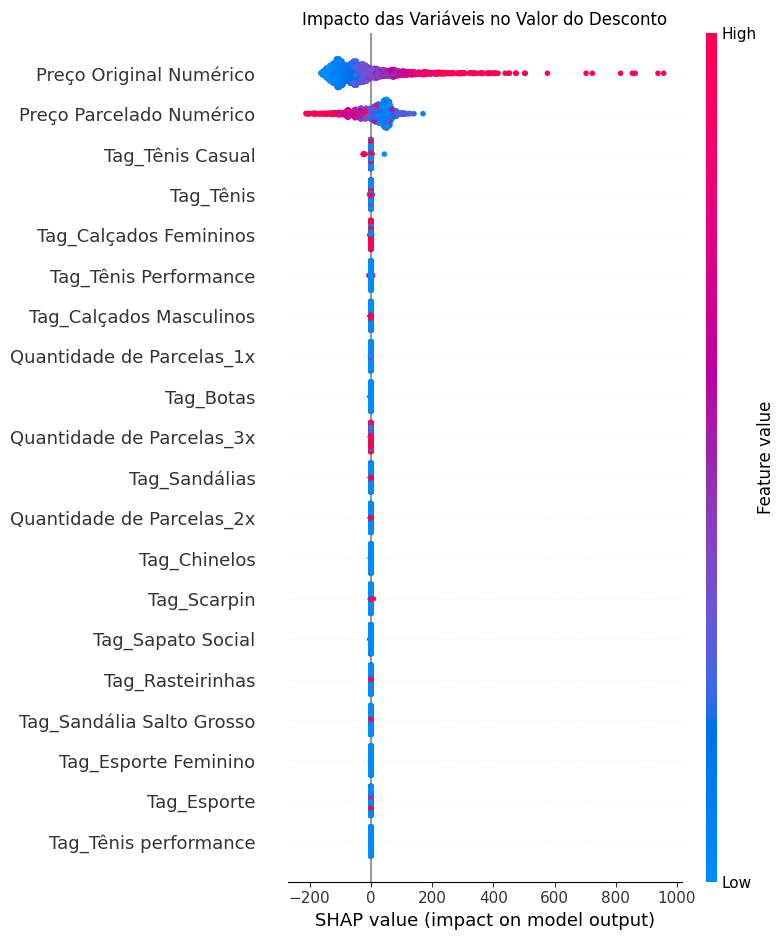

In [7]:
print("--- SHAP: Análise do Modelo de Previsão (Média) ---")
explainer_media = shap.TreeExplainer(modelo_media)
shap_values_media = explainer_media.shap_values(X_teste)

plt.figure()
plt.title("Impacto das Variáveis no Valor do Desconto")
shap.summary_plot(shap_values_media, X_teste, show=False)
plt.show()

- O summary plot do SHAP revela que o "Preço Original Numérico" é o principal motor do modelo preditivo: valores altos desta variável (pontos vermelhos) empurram fortemente o valor previsto do desconto para cima, enquanto valores baixos (pontos azuis) reduzem a previsão.
- A variável "Preço Parcelado Numérico" atua como o segundo fator de maior influência, com efeito inverso: valores altos (pontos vermelhos) puxam a previsão de desconto para baixo, e valores baixos (pontos azuis) a elevam.
- Variáveis categóricas derivadas de tags (como "Tag_Tênis Casual", "Tag_Calçados Femininos") e as variáveis de "Quantidade de Parcelas" exercem um impacto quase nulo na predição pontual do desconto, com seus pontos concentrados no eixo zero. O modelo funciona, essencialmente, aprendendo a relação matemática entre os preços numéricos (Original e Parcelado) para prever o desconto final.


--- SHAP: Análise do Modelo de Incerteza (Variância) ---


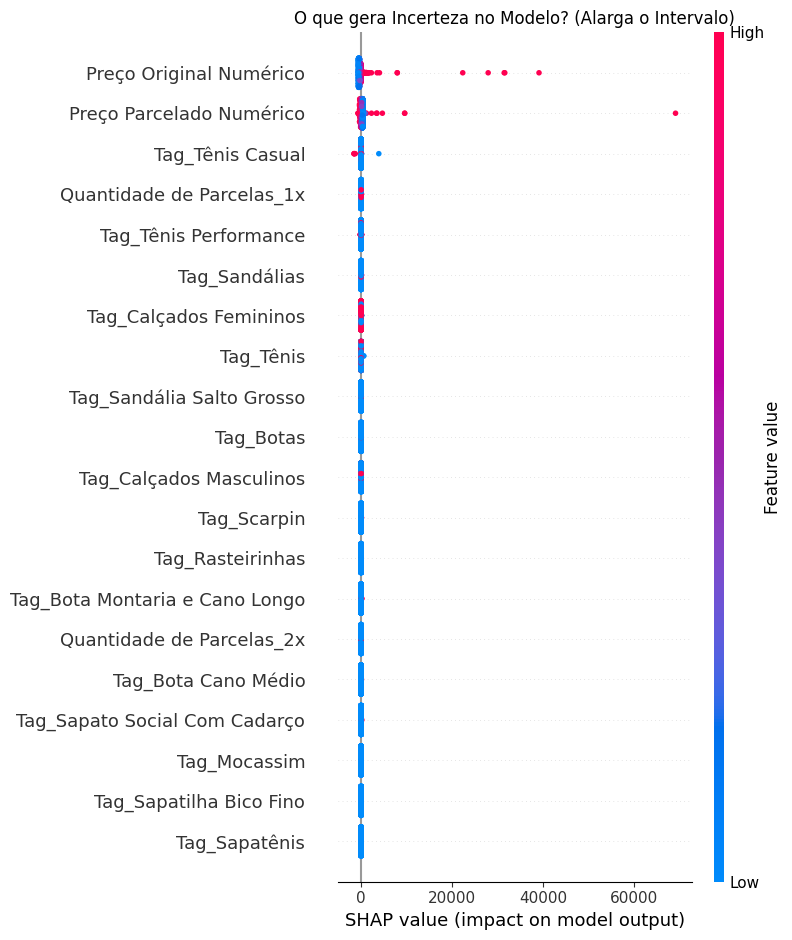

In [8]:
print("\n--- SHAP: Análise do Modelo de Incerteza (Variância) ---")
explainer_variancia = shap.TreeExplainer(modelo_variancia)
shap_values_variancia = explainer_variancia.shap_values(X_teste)

plt.figure()
plt.title("O que gera Incerteza no Modelo? (Alarga o Intervalo)")
shap.summary_plot(shap_values_variancia, X_teste, show=False)
plt.show()

- O gráfico de resumo do SHAP revela que o "Preço Original Numérico" é o principal motor do modelo de incerteza (variância): valores altos desta variável (pontos vermelhos) empurram fortemente a incerteza para cima, alargando o intervalo, enquanto valores baixos (pontos azuis) mantêm o impacto próximo de zero.
- A variável "Preço Parcelado Numérico" atua como o segundo fator de maior influência, apresentando um comportamento semelhante em vez de inverso: valores altos (pontos vermelhos) também aumentam a variância prevista, puxando a incerteza para a direita, enquanto valores baixos (pontos azuis) não contribuem para o alargamento do intervalo.
- As variáveis categóricas derivadas de tags (como "Tag_Tênis Casual", "Tag_Tênis Performance") e as variáveis de "Quantidade de Parcelas" exercem um impacto quase nulo na incerteza do modelo, com os seus pontos rigidamente concentrados no eixo zero. O modelo de variância funciona, essencialmente, identificando que as magnitudes extremas dos preços numéricos (Original e Parcelado) são os fatores que geram incerteza e ditam a largura das margens de segurança.


Análise Isolada: Produto de Índice 2096 (Maior Incerteza)


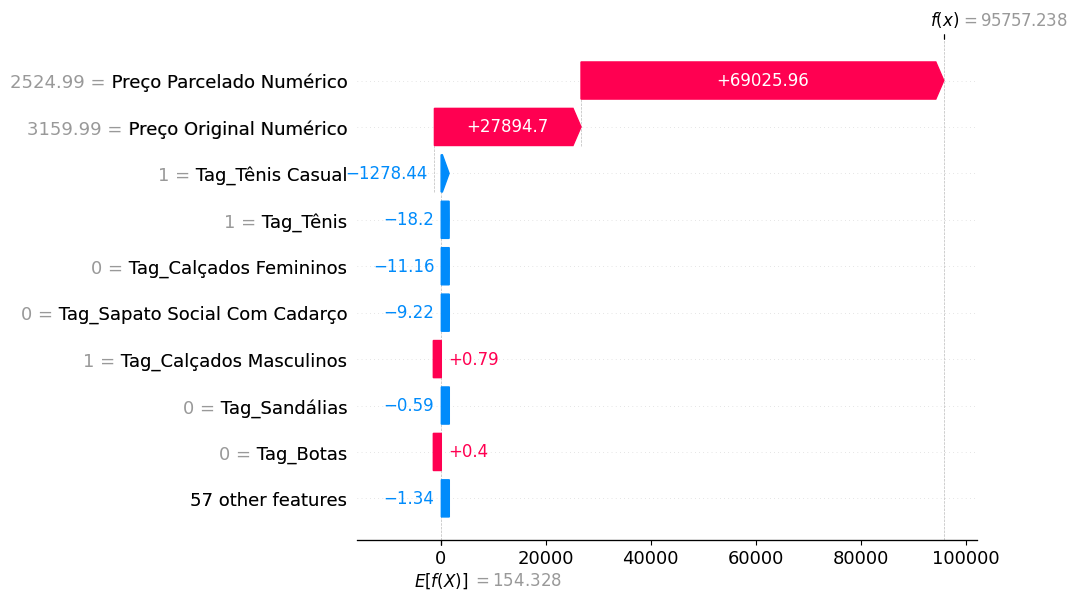

In [9]:
# Investigação Local (Instância de maior incerteza)
indice_maior_incerteza = np.argmax(escala_teste)
shap.initjs()

print(f"\nAnálise Isolada: Produto de Índice {indice_maior_incerteza} (Maior Incerteza)")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_variancia[indice_maior_incerteza], 
        base_values=explainer_variancia.expected_value, 
        data=X_teste.iloc[indice_maior_incerteza].values, 
        feature_names=X_teste.columns
    )
)

- O gráfico de cascata (waterfall) detalha a predição da variância para a instância (Produto de Índice 2096) em que o modelo apresentou a maior incerteza na base de dados.
- A variância prevista saltou de um valor base esperado de 154.328 para um extremo de 95757.238.
- Esse salto massivo foi impulsionado de forma esmagadora por apenas duas características numéricas: o "Preço Parcelado Numérico" de R$ 2524.99 injetou +69025.96 na variância, e o "Preço Original Numérico" de R$ 3159.99 adicionou outros +27894.7.
- Variáveis categóricas tiveram um efeito apenas residual para tentar frear essa incerteza, como a presença da "Tag_Tênis Casual" que reduziu a variância em minúsculos -1278.44. Isso confirma que o alto valor financeiro do produto atua isoladamente como o gatilho principal para o alargamento extremo da margem de erro estatística.

## 8. Conclusão e Comparação Visual
Abaixo, visualizamos uma amostra de 10 produtos comparando lado a lado as duas abordagens. Nota-se que o método adaptativo reage à complexidade da amostra individual: em produtos previsíveis ele é rigoroso (intervalo curto), mas provê espaço de segurança maior em cenários de alta incerteza detectada pelo modelo de variância.

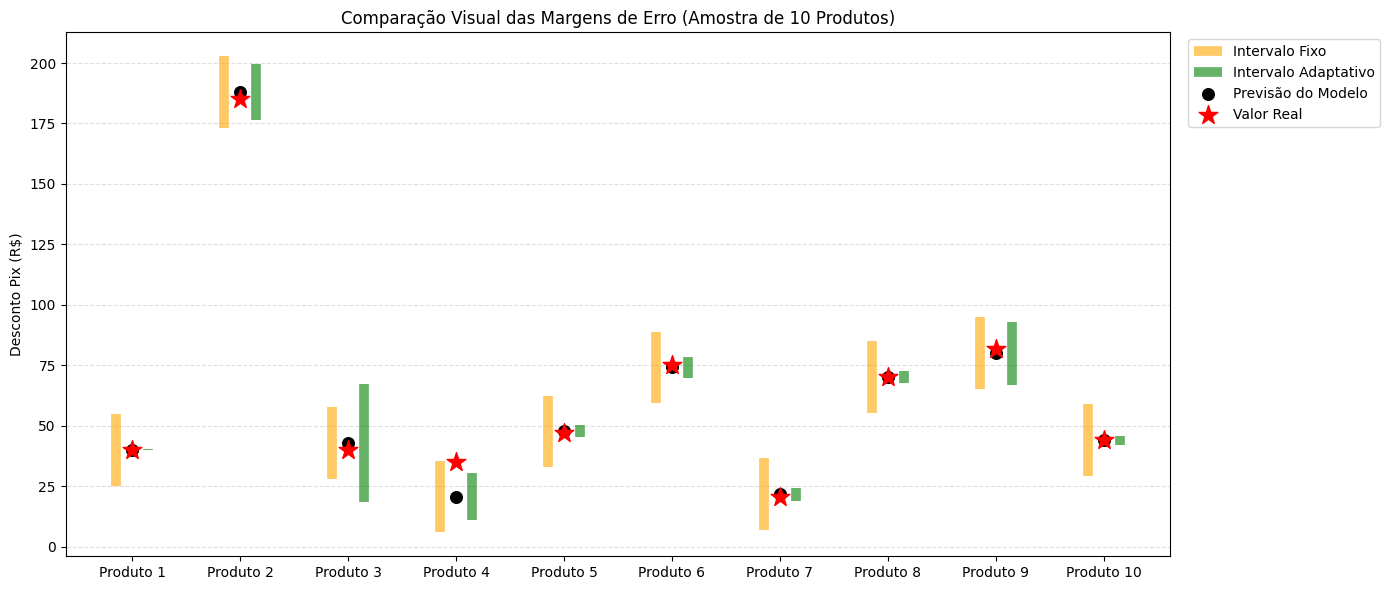

In [10]:
intervalos = pd.DataFrame({
    "y_real": y_teste,
    "pred_comum": pred_teste,
    "baixo_comum": baixo_comum,
    "alto_comum": alto_comum,
    "pred_variancia": pred_teste_adapt,
    "baixo_variancia": baixo_adapt,
    "alto_variancia": alto_adapt,
})

df_plot = intervalos.head(10).reset_index(drop=True)
x = np.arange(len(df_plot))
deslocamento = 0.15 

plt.figure(figsize=(14, 6))

# CP Fixo
plt.vlines(x - deslocamento, ymin=df_plot['baixo_comum'], ymax=df_plot['alto_comum'], 
           color='orange', linewidth=7, alpha=0.6, label='Intervalo Fixo')

# CP Adaptativo
plt.vlines(x + deslocamento, ymin=df_plot['baixo_variancia'], ymax=df_plot['alto_variancia'], 
           color='green', linewidth=7, alpha=0.6, label='Intervalo Adaptativo')

# Previsão pontual e real
plt.scatter(x, df_plot['pred_comum'], color='black', marker='o', s=70, zorder=4, label='Previsão do Modelo')
plt.scatter(x, df_plot['y_real'], color='red', marker='*', s=200, zorder=5, label='Valor Real')

plt.xticks(x, [f"Produto {i+1}" for i in range(10)])
plt.ylabel("Desconto Pix (R$)")
plt.title("Comparação Visual das Margens de Erro (Amostra de 10 Produtos)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') 
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout() 
plt.show()

- O comparativo visual de 10 produtos ilustra a dinâmica do Conformal Prediction Adaptativo (barras verdes) em contraste com o intervalo Fixo (barras laranjas).
- Para predições onde o modelo possui alta confiança, o intervalo adaptativo verde comprime-se de forma expressiva (como evidenciado nos Produtos 1, 5, 7, 8 e 10), apresentando uma precisão muito superior à da barra laranja e ainda assim garantindo a cobertura do "Valor Real" (estrela vermelha).
- A individualização do risco estatístico fica clara nas exceções mostradas no gráfico: no Produto 3, o modelo detectou maior incerteza e alargou a barra verde para além da margem laranja; já no Produto 4, a compressão do intervalo adaptativo ao redor da previsão foi tão rígida que o valor real acabou ficando de fora da faixa verde.
- A abordagem adaptativa otimiza a tomada de decisão comercial: em vez de aplicar uma margem de erro engessada e desnecessariamente larga para todos os itens, ela entrega uma banda justa e enxuta para produtos com comportamento comum, reservando as expansões de segurança apenas para características que realmente gerem incerteza matemática.